CICIDS Loaded: (2313810, 78)

Model Trained on CICIDS
NS3 dataset created successfully

===== SAMPLE OUTPUT =====
       Prediction                                  Strategy
20469           1                         BLOCK DATA MINING
4951            0                          NO ACTION (SAFE)
6952            0                          NO ACTION (SAFE)
26698           4  SECURE NETWORK (CYBER ESPIONAGE DEFENSE)
20049           1                         BLOCK DATA MINING
18305           0                          NO ACTION (SAFE)
25511           3        RANDOMIZE ROUTE (TRACKING DEFENSE)
23753           3        RANDOMIZE ROUTE (TRACKING DEFENSE)
9616            0                          NO ACTION (SAFE)
30584           4  SECURE NETWORK (CYBER ESPIONAGE DEFENSE)

===== ACCURACY =====
0.9844738229093465

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     20000
           1       0.92      0.91      0.

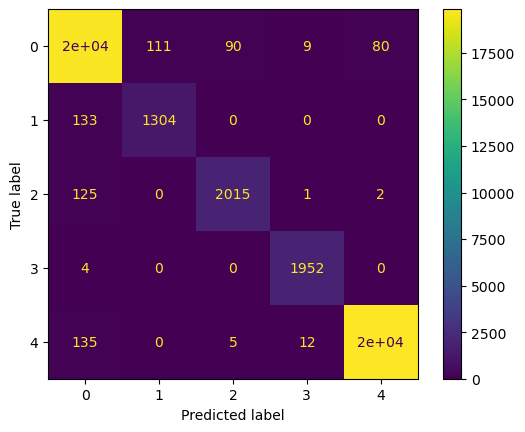


===== PREDICTION DISTRIBUTION =====
{0: 20107, 1: 1415, 2: 2110, 3: 1974, 4: 19930}


In [4]:
# ================== IMPORTS ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# ================== LOAD CICIDS ==================
files = [
    "Benign-Monday-no-metadata.parquet",
    "Botnet-Friday-no-metadata.parquet",
    "Bruteforce-Tuesday-no-metadata.parquet",
    "DDoS-Friday-no-metadata.parquet",
    "DoS-Wednesday-no-metadata.parquet",
    "Infiltration-Thursday-no-metadata.parquet",
    "Portscan-Friday-no-metadata.parquet",
    "WebAttacks-Thursday-no-metadata.parquet"
]

dfs = [pd.read_parquet(f) for f in files]
cicids = pd.concat(dfs, ignore_index=True)

print("CICIDS Loaded:", cicids.shape)

# ================== PPT ATTACK MAPPING ==================
def map_attack(label):
    label = str(label).lower()

    if "benign" in label:
        return 0  # Normal
    elif "bot" in label:
        return 1  # Data Mining
    elif "web" in label:
        return 2  # Eavesdropping
    elif "portscan" in label:
        return 3  # Tracking
    else:
        return 4  # Cyber Espionage

cicids["AttackLabel"] = cicids["Label"].apply(map_attack)

# ================== FEATURE EXTRACTION ==================
df = pd.DataFrame()

df["packet_size"] = cicids["Avg Packet Size"]
df["delay"] = cicids["Flow Duration"]
df["protocol"] = cicids["Protocol"]
df["fwd_packets"] = cicids["Total Fwd Packets"]
df["bwd_packets"] = cicids["Total Backward Packets"]
df["bytes_per_sec"] = cicids["Flow Bytes/s"]
df["AttackLabel"] = cicids["AttackLabel"]

df = df.dropna()

# ================== BALANCE TRAIN DATA ==================
balanced_df = pd.DataFrame()

for i in range(5):
    class_data = df[df["AttackLabel"] == i]

    if len(class_data) > 0:
        sample_size = min(10000, len(class_data))
        balanced_df = pd.concat([
            balanced_df,
            class_data.sample(n=sample_size, random_state=42)
        ])

train_df = balanced_df

# ================== TRAIN ==================
features = [
    "packet_size",
    "delay",
    "protocol",
    "fwd_packets",
    "bwd_packets",
    "bytes_per_sec"
]

X_train = train_df[features]
y_train = train_df["AttackLabel"]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("\nModel Trained on CICIDS")

# ================== GENERATE MULTI-CLASS NS3 (SAFE) ==================
ns3_parts = []

for i in range(5):
    class_data = cicids[cicids["AttackLabel"] == i]

    if len(class_data) > 0:
        sample_size = min(20000, len(class_data))  # SAFE SAMPLING
        ns3_parts.append(class_data.sample(sample_size, random_state=42))

ns3_df = pd.concat(ns3_parts)

print("NS3 dataset created successfully")

# ================== CREATE TEST DATA ==================
test_df = pd.DataFrame()

test_df["packet_size"] = ns3_df["Avg Packet Size"]
test_df["delay"] = ns3_df["Flow Duration"]
test_df["protocol"] = ns3_df["Protocol"]
test_df["fwd_packets"] = ns3_df["Total Fwd Packets"]
test_df["bwd_packets"] = ns3_df["Total Backward Packets"]
test_df["bytes_per_sec"] = ns3_df["Flow Bytes/s"]
test_df["AttackLabel"] = ns3_df["AttackLabel"]

test_df = test_df.dropna()

# ================== TEST ==================
X_test = test_df[features]
y_test = test_df["AttackLabel"]

X_test = scaler.transform(X_test)

predictions = model.predict(X_test)

# ================== GAME THEORY STRATEGY ==================
def game_strategy(action):
    if action == 0:
        return "NO ACTION (SAFE)"
    elif action == 1:
        return "BLOCK DATA MINING"
    elif action == 2:
        return "ENCRYPT CHANNEL (EAVESDROPPING DEFENSE)"
    elif action == 3:
        return "RANDOMIZE ROUTE (TRACKING DEFENSE)"
    elif action == 4:
        return "SECURE NETWORK (CYBER ESPIONAGE DEFENSE)"

actions = [game_strategy(p) for p in predictions]

# ================== RESULTS ==================
results_df = pd.DataFrame({
    "Prediction": predictions,
    "Strategy": actions
})

print("\n===== SAMPLE OUTPUT =====")
print(results_df.sample(10))

print("\n===== ACCURACY =====")
print(accuracy_score(y_test, predictions))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, predictions))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, predictions))

# ================== VISUAL CONFUSION MATRIX ==================
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()

print("\n===== PREDICTION DISTRIBUTION =====")
unique, counts = np.unique(predictions, return_counts=True)
print(dict(zip(unique, counts)))